In [ ]:
from google.colab import files
uploaded = files.upload()

Saving GOGL.csv to GOGL.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('GOGL.csv')  # or your stock file
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1997-02-07,112.500,113.125,108.125,110.0000,13.785553,1745800.0
1,1997-02-10,110.000,110.000,106.250,107.1875,13.433074,324200.0
2,1997-02-11,106.875,109.375,106.875,108.1250,13.550564,156200.0
3,1997-02-12,108.750,108.750,106.250,106.8750,13.393909,99300.0
4,1997-02-13,106.250,106.875,106.250,106.2500,13.315585,149400.0


In [ ]:
df = df.sort_values('Date')

data = df['Close'].values.reshape(-1,1)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [ ]:
X = []
y = []

time_steps = 60

for i in range(time_steps, len(data_scaled)):
    X.append(data_scaled[i-time_steps:i])
    y.append(data_scaled[i])

X, y = np.array(X), np.array(y)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X.shape[1],1)))
model.add(LSTM(50))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
history = model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - loss: 0.0074
Epoch 2/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 6.5379e-04
Epoch 3/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 5.8893e-04
Epoch 4/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 5.8773e-04
Epoch 5/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - loss: 5.2073e-04
Epoch 6/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 4.4022e-04
Epoch 7/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - loss: 4.3058e-04
Epoch 8/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - loss: 4.0742e-04
Epoch 9/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - loss: 3.9123e-04
Epoch 10/10
145/145 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - loss: 3.8610e-04


In [ ]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


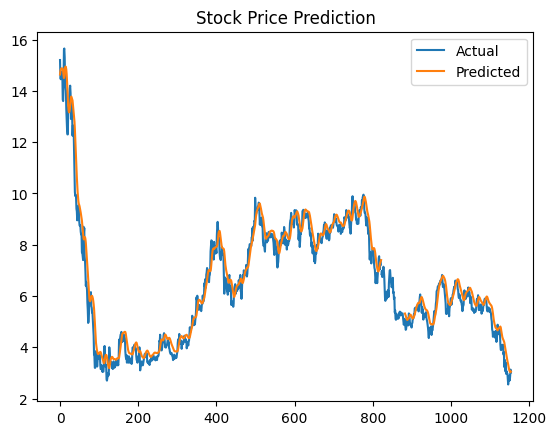

In [ ]:
actual = scaler.inverse_transform(y_test)

plt.plot(actual, label='Actual')
plt.plot(predictions, label='Predicted')
plt.legend()
plt.title('Stock Price Prediction')
plt.show()